# Maps of percent change

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import regionmask
import cartopy.crs as ccrs

import xclimate as xclim

%load_ext autoreload
%autoreload 2

In [2]:
client_cluster = xclim.create_dask_cluster(
    account='UWAS0155',
    nworkers=4,
    ncores=1,
    nmem='4GB',
    walltime='02:00:00'
)

account:  UWAS0155
nworkers: 4
ncores:   1
nmemory:  4GB
walltime: 02:00:00
{'PBSCluster-3': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-0': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-2': <dask_jobqueue.pbs.PBSJob: status=running>, 'PBSCluster-1': <dask_jobqueue.pbs.PBSJob: status=running>}

To view the dask dashboard
Run the following command in your local terminal:
> ssh -N -L 8787:128.117.211.162:8787 bbuchovecky@casper.hpc.ucar.edu
Open the following link in your local browser:
> http://localhost:8787/status


In [ ]:
# xclim.close_dask_cluster(client_cluster)

In [3]:
grid_ppe = xclim.load_fhist_ppe_grid()
grid_lens = xclim.load_cesm2le_grid()
grid_goga = xclim.load_goga2_grid()

NONGLC_PCT_THRESHOLD = 100  # maximum allowable percent of glaciated land for a NON-glaciated gridcell

nonglc_mask_ppe = grid_ppe.PCT_GLC <= NONGLC_PCT_THRESHOLD
nonglc_mask_lens = grid_lens.PCT_GLC <= NONGLC_PCT_THRESHOLD
nonglc_mask_goga = grid_goga.PCT_GLC <= NONGLC_PCT_THRESHOLD

In [5]:
tperiod = slice("1950-01", "2014-12")

In [70]:
variables = [
    "EFLX_LH_TOT_month_1",
    "TLAI_month_1",
    "TSA_month_1",
    # "SOILLIQ_month_1",
    "TOTSOILLIQ_month_1",
    "SOILWATER_10CM_month_1",
]
load_zarr = False

fhist = {}
ohist = {}
for v in variables:
    print(f"  {v}")
    name = "_".join(v.split("_")[:-2])

    fhist[v] = (
        xclim.load_fhist(v, load_zarr=load_zarr, keep_var_only=True)[name]
        .sel(time=tperiod)
        .reindex_like(grid_ppe, method="nearest", tolerance=1e-3)
        .where(nonglc_mask_ppe)
        # .chunk({'time': -1, 'lat': -1, 'lon': -1})
        # .persist()
    )
    fhist[v].attrs["masks"] = f"gridcell percent glaciated land <= {NONGLC_PCT_THRESHOLD}"

    ohist[v] = (
        xclim.load_offlhist(v, load_zarr=load_zarr, keep_var_only=True)[name]
        .sel(time=tperiod)
        .reindex_like(grid_ppe, method="nearest", tolerance=1e-3)
        .where(nonglc_mask_ppe)
        # .chunk({'time': -1, 'lat': -1, 'lon': -1})
        # .persist()
    )
    ohist[v].attrs["masks"] = f"gridcell percent glaciated land <= {NONGLC_PCT_THRESHOLD}"

  EFLX_LH_TOT_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
  TLAI_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
  TSA_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
  TOTSOILLIQ_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27
  SOILWATER_10CM_month_1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 

In [71]:
# fhist['TSA_month_1'] = fhist['TSA_month_1'] - 273.15
# ohist['TSA_month_1'] = ohist['TSA_month_1'] - 273.15

In [72]:
tsubset = slice('1995-01', '2014-12')

In [73]:
cv = {}
delta = {}
pct_delta = {}
pct_rng_delta = {}
for v in variables:
    cv[v] = fhist[v].sel(time=tsubset).mean(dim='time').std(dim='member') / fhist[v].sel(time=tsubset).mean(dim=['time', 'member'])

    mem = fhist[v].sel(time=tsubset, member=slice(1, None)).mean(dim='time')
    ctl = fhist[v].sel(time=tsubset, member=0).mean(dim='time')

    delta[v] = mem - ctl
    pct_delta[v] = (abs(mem - ctl) / ctl) * 100
    pct_rng_delta[v] = pct_delta[v].max(dim='member') - pct_delta[v].min(dim='member')

    delta[v] = delta[v].persist()
    cv[v] = cv[v].persist()
    pct_delta[v] = pct_delta[v].persist()
    pct_rng_delta[v] = pct_rng_delta[v].persist()

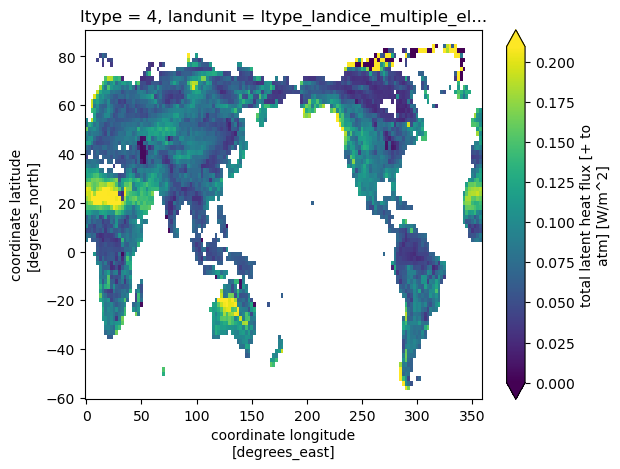

In [62]:
cv["EFLX_LH_TOT_month_1"].where(grid_ppe.PCT_GLC < 50).sel(lat=slice(-60, None)).plot(vmin=0, robust=True)

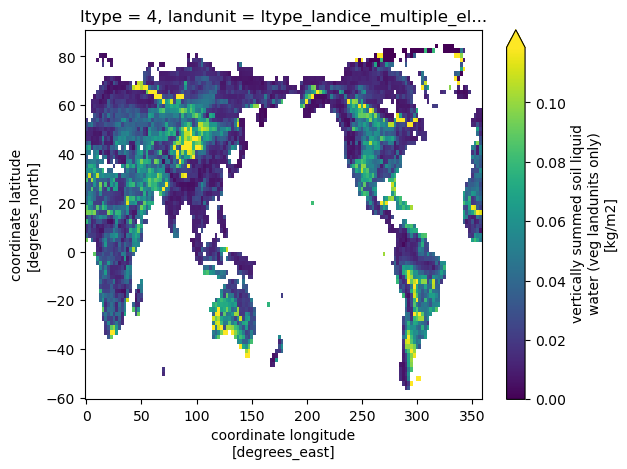

In [74]:
cv["TOTSOILLIQ_month_1"].where(grid_ppe.PCT_GLC < 50).sel(lat=slice(-60, None)).plot(vmin=0, robust=True)

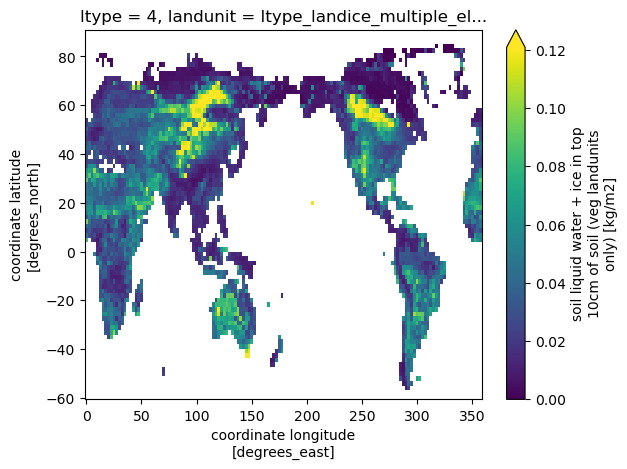

In [76]:
cv["SOILWATER_10CM_month_1"].where(grid_ppe.PCT_GLC < 50).sel(lat=slice(-60, None)).plot(vmin=0, robust=True)

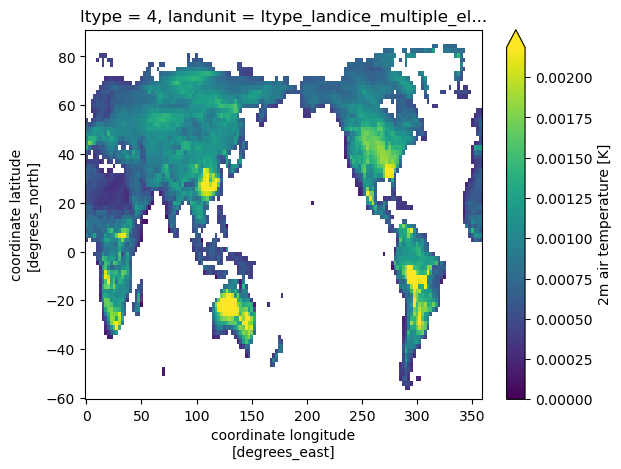

In [63]:
cv["TSA_month_1"].where(grid_ppe.PCT_GLC < 50).sel(lat=slice(-60, None)).plot(vmin=0, robust=True)

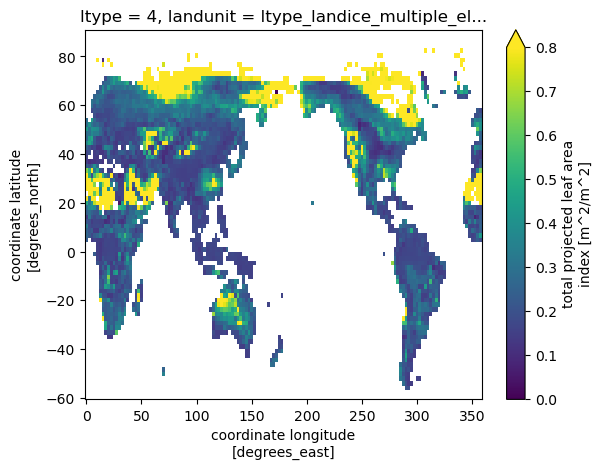

In [65]:
cv["TLAI_month_1"].where(grid_ppe.PCT_GLC < 50).sel(lat=slice(-60, None)).plot(vmin=0, vmax=0.8, robust=True)

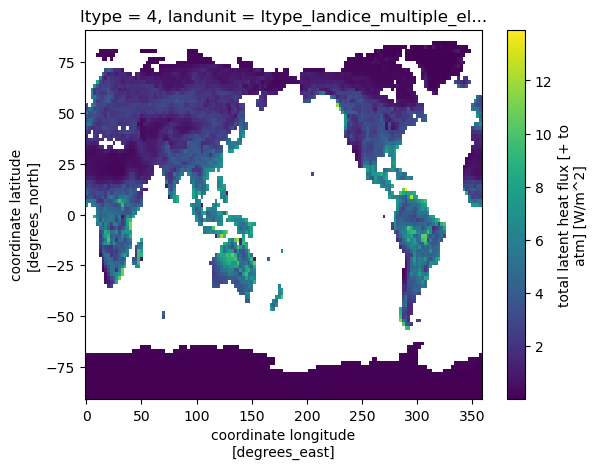

In [ ]:
delta["EFLX_LH_TOT_month_1"].std(dim='member').plot()

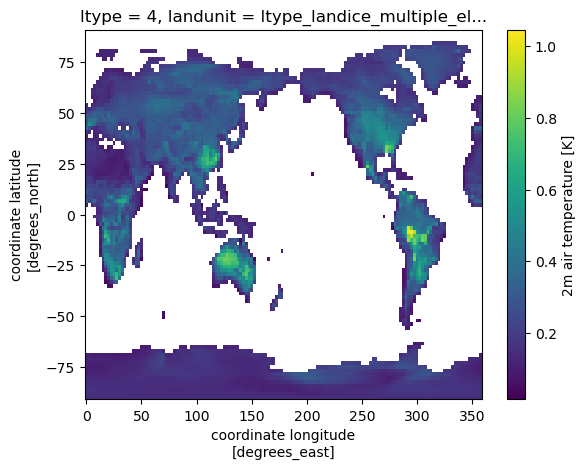

In [29]:
delta["TSA_month_1"].std(dim='member').plot()

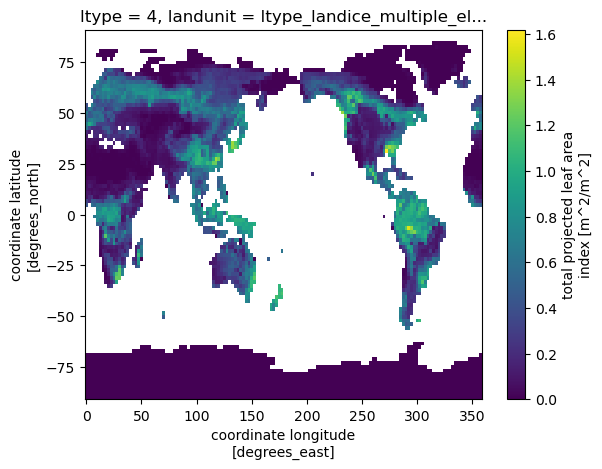

In [30]:
delta["TLAI_month_1"].std(dim='member').plot()

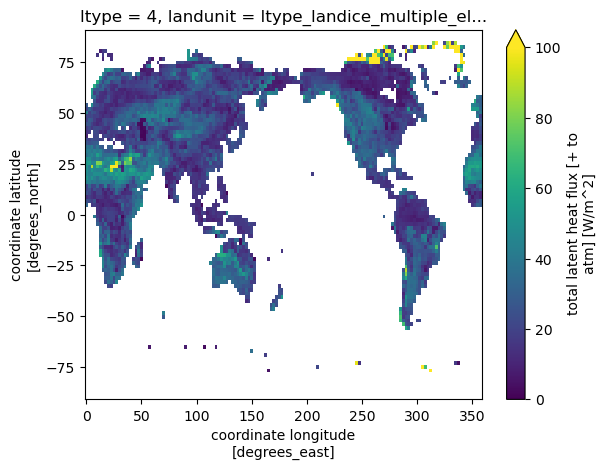

In [21]:
rng_delta_pct['EFLX_LH_TOT_month_1'].where(grid_ppe.PCT_GLC < 50).plot(vmin=0, vmax=100)

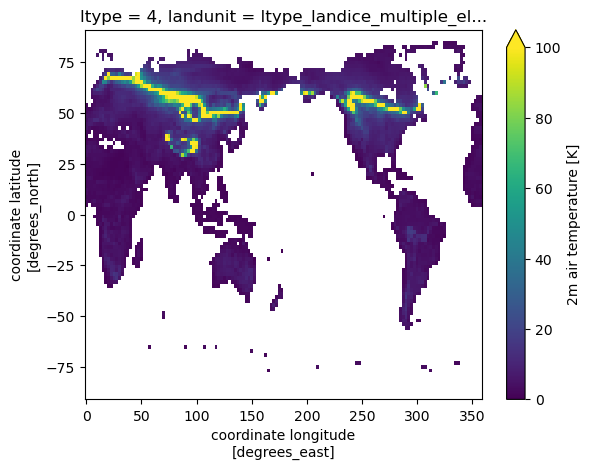

In [22]:
rng_delta_pct['TSA_month_1'].where(grid_ppe.PCT_GLC < 50).plot(vmin=0, vmax=100)

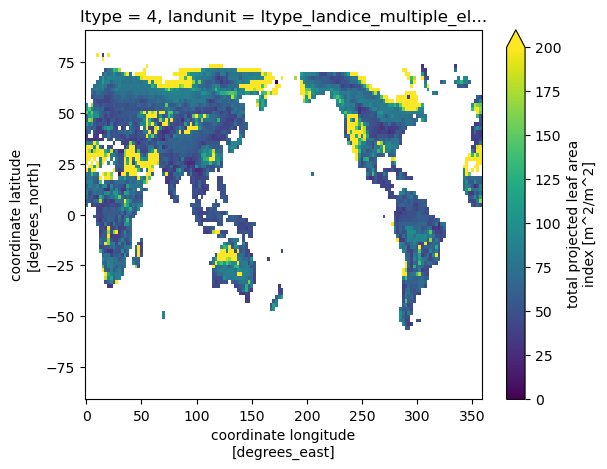

In [23]:
rng_delta_pct['TLAI_month_1'].where(grid_ppe.PCT_GLC < 50).plot(vmin=0, vmax=200)